# Semiconductor Yield Intelligence  
## 05 – Batch Inference Demonstration  

---

### 🎯 Objective

Demonstrate real-time wafer defect classification.

This notebook simulates:

Incoming wafer → Model → Prediction

Used during final presentation to show working Proof-of-Concept.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

## 🔹 Step 1 – Reload Model Architecture

We reconstruct the model architecture  
before loading saved weights.el

In [3]:
import torch
import torch.nn as nn
import numpy as np

# Re-define model architecture
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1,16,3,padding=1)
        self.pool = nn.MaxPool2d(2,2)
        self.fc1 = nn.Linear(16*16*16,64)
        self.fc2 = nn.Linear(64,num_classes)

    def forward(self,x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = x.view(x.size(0),-1)
        x = torch.relu(self.fc1(x))
        return self.fc2(x)

## 🔹 Step 2 – Load Test Dataset

We randomly select one wafer map  
to simulate real-world inference.

In [6]:
X_test = np.load("/home/sagemaker-user/MLops-Project-AAI-540/data/X_test.npy")
y_test = np.load("/home/sagemaker-user/MLops-Project-AAI-540/data/y_test.npy")

num_classes = len(np.unique(y_test))

model = SimpleCNN(num_classes)
model.load_state_dict(torch.load("/home/sagemaker-user/MLops-Project-AAI-540/data/model.pt"))
model.eval()

SimpleCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=4096, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=5, bias=True)
)

## 🔹 Step 3 – Select Random Wafer Map

This simulates a new wafer arriving from inspection equipment.

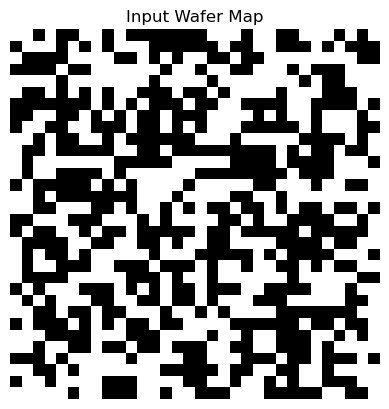

In [7]:
idx = np.random.randint(0,len(X_test))
sample = X_test[idx]

plt.imshow(sample, cmap='gray')
plt.title("Input Wafer Map")
plt.axis("off")
plt.show()

## 🔹 Step 4 – Perform Prediction

Model processes the wafer and outputs predicted defect class.

In [8]:
with torch.no_grad():
    pred = model(torch.tensor(sample).unsqueeze(0).unsqueeze(0).float())
    predicted_class = torch.argmax(pred).item()

print("Predicted Class:", predicted_class)

Predicted Class: 0


# 🎉 Live Demonstration Complete

The system successfully:

✔ Loads trained model  
✔ Accepts wafer input  
✔ Performs classification  
✔ Outputs prediction  

---

## 📌 In Production

This inference pipeline would:

- Run as batch job
- Integrate with inspection system
- Log predictions
- Trigger alerts for high-risk defects